# Norm Growth and Stability

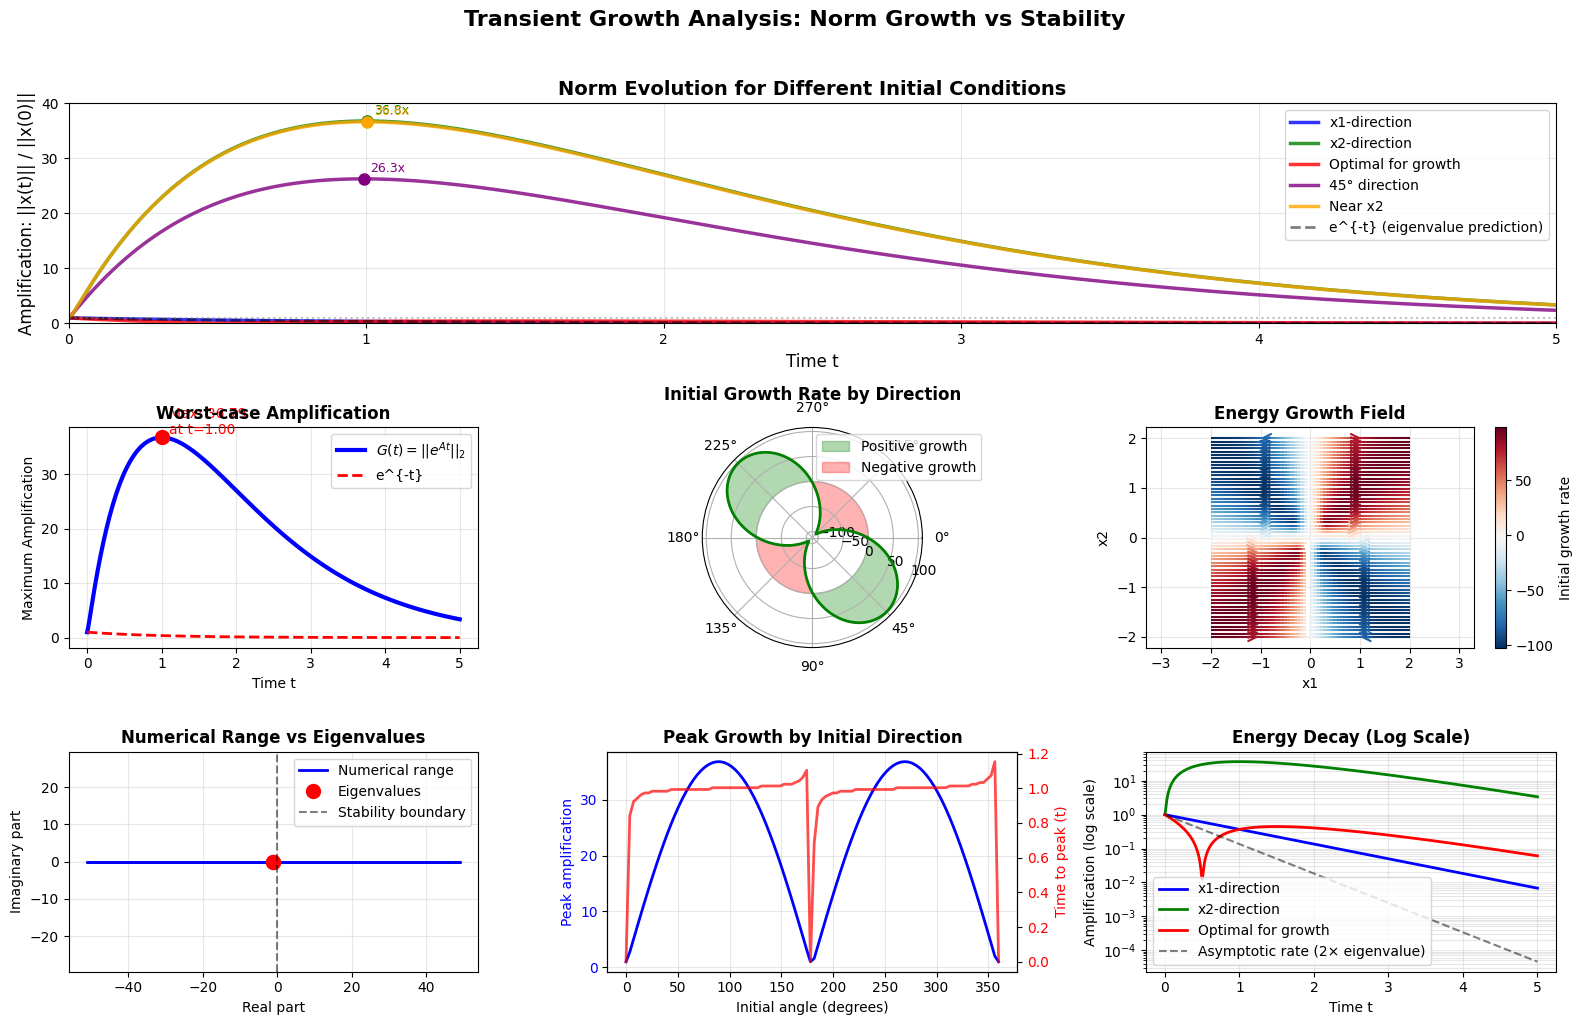

KEY INSIGHTS: Norm Growth vs Stability

1. EIGENVALUE STABILITY:
   • Eigenvalues: λ = -1.00, -1.00
   • Both have negative real part → Asymptotically stable
   • Would predict monotonic decay as e^{-t}

2. TRANSIENT GROWTH MECHANISM:
   • Matrix is non-normal: A*A^T ≠ A^T*A
   • Off-diagonal term (100) couples states
   • Initial condition aligned with [0,1] gets amplified via:
       x1(t) = (x1(0) + 100*x2(0)*t)*e^{-t}
       The 100*t term creates temporary growth

3. MAXIMUM AMPLIFICATION:
   • Maximum G_max ≈ 36.79 at t ≈ 1.00
   • This is ~36.8× the initial norm!
   • Numerical abscissa ω(A) = 49 → initial growth rate up to 49

4. PRACTICAL IMPLICATIONS:
   • In physical systems, this growth can trigger nonlinearities
   • System may appear unstable in finite time observations
   • Stability margin is misleading without transient analysis



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# System definition
A = np.array([[-1, 100], [0, -1]])

def exp_At(t):
    """Matrix exponential for A"""
    return np.exp(-t) * np.array([[1, 100*t], [0, 1]])

def norm_evolution(x0, t_max=5, n_points=500):
    """Compute norm evolution for given initial condition"""
    t = np.linspace(0, t_max, n_points)
    norms = np.zeros_like(t)
    for i, ti in enumerate(t):
        x_t = exp_At(ti) @ x0
        norms[i] = np.linalg.norm(x_t)
    return t, norms, norms / np.linalg.norm(x0)

def G_t(t):
    """Maximum amplification at time t (operator norm)"""
    M = exp_At(t)
    sigma = np.linalg.svd(M, compute_uv=False)
    return sigma[0]

# Create comprehensive figure
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 3, figure=fig)

# ====================================
# Plot 1: Norm Evolution (Main)
# ====================================
ax1 = fig.add_subplot(gs[0, :])
t = np.linspace(0, 5, 500)

# Critical initial condition that maximizes transient growth
# (This is the right singular vector of e^{At} at t_peak ≈ 1)
# For large t_peak, the optimal initial condition is approximately [0, 1]
x0_optimal = np.array([-50, 1])
x0_optimal = x0_optimal / np.linalg.norm(x0_optimal)

initial_conditions = [
    (np.array([1, 0]), 'x1-direction', 'blue'),
    (np.array([0, 1]), 'x2-direction', 'green'),
    (x0_optimal, 'Optimal for growth', 'red'),
    (np.array([0.707, 0.707]), '45° direction', 'purple'),
    (np.array([0.1, 0.995]), 'Near x2', 'orange')
]

for x0, label, color in initial_conditions:
    t_vals, norms, ampl = norm_evolution(x0)
    ax1.plot(t_vals, ampl, color=color, linewidth=2.5, alpha=0.8, label=label)
    # Mark peak if it exists
    peak_idx = np.argmax(ampl)
    if ampl[peak_idx] > 1.05:  # Only mark if significant growth
        ax1.plot(t_vals[peak_idx], ampl[peak_idx], 'o', color=color, markersize=8)
        ax1.annotate(f'{ampl[peak_idx]:.1f}x',
                    xy=(t_vals[peak_idx], ampl[peak_idx]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, color=color)

# Plot pure exponential decay (what eigenvalues predict)
ax1.plot(t, np.exp(-t), 'k--', linewidth=2, alpha=0.5, label='e^{-t} (eigenvalue prediction)')

ax1.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
ax1.set_xlabel('Time t', fontsize=12)
ax1.set_ylabel('Amplification: ||x(t)|| / ||x(0)||', fontsize=12)
ax1.set_title('Norm Evolution for Different Initial Conditions', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 5])
ax1.set_ylim([0, 40])

# ====================================
# Plot 2: Maximum Amplification
# ====================================
ax2 = fig.add_subplot(gs[1, 0])
G_vals = np.array([G_t(ti) for ti in t])

ax2.plot(t, G_vals, 'b-', linewidth=3, label=r'$G(t) = ||e^{At}||_2$')
ax2.plot(t, np.exp(-t), 'r--', linewidth=2, label='e^{-t}')

# Find and mark maximum
t_peak = t[np.argmax(G_vals)]
G_max = G_vals[np.argmax(G_vals)]
ax2.plot(t_peak, G_max, 'ro', markersize=10)
ax2.text(t_peak+0.1, G_max, f'Max: {G_max:.2f}\nat t={t_peak:.2f}',
         fontsize=10, verticalalignment='bottom', color='red')

ax2.set_xlabel('Time t')
ax2.set_ylabel('Maximum Amplification')
ax2.set_title('Worst-case Amplification', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ====================================
# Plot 3: Initial Growth Rate vs Angle
# ====================================
ax3 = fig.add_subplot(gs[1, 1], projection='polar')
theta = np.linspace(0, 2*np.pi, 200)
growth_rates = []

for th in theta:
    x0 = np.array([np.cos(th), np.sin(th)])
    # d/dt(||x||^2) at t=0 = 2 * x0^T * sym(A) * x0
    # where sym(A) = (A + A^T)/2
    symA = (A + A.T) / 2
    growth = 2 * (x0.T @ symA @ x0)
    growth_rates.append(growth)

ax3.plot(theta, growth_rates, 'g-', linewidth=2)
ax3.fill_between(theta, 0, growth_rates, where=np.array(growth_rates)>0,
                 color='green', alpha=0.3, label='Positive growth')
ax3.fill_between(theta, 0, growth_rates, where=np.array(growth_rates)<0,
                 color='red', alpha=0.3, label='Negative growth')
ax3.set_theta_zero_location('E')
ax3.set_theta_direction(-1)
ax3.set_title('Initial Growth Rate by Direction', fontweight='bold', pad=20)
ax3.grid(True)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

# ====================================
# Plot 4: Energy Phase Portrait
# ====================================
ax4 = fig.add_subplot(gs[1, 2])

# Create grid of initial conditions
x1_vals = np.linspace(-2, 2, 15)
x2_vals = np.linspace(-2, 2, 15)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Compute initial growth rate at each point
dE_dt = np.zeros_like(X1)
for i in range(len(x1_vals)):
    for j in range(len(x2_vals)):
        x0 = np.array([X1[i, j], X2[i, j]])
        if np.linalg.norm(x0) > 0:
            symA = (A + A.T) / 2
            dE_dt[i, j] = 2 * (x0.T @ symA @ x0) / np.linalg.norm(x0)**2

# Plot streamlines
color_plot = ax4.streamplot(X1, X2, dE_dt, np.zeros_like(dE_dt),
                           color=dE_dt, cmap='RdBu_r', linewidth=1.5,
                           arrowstyle='->', arrowsize=1.5, density=2)
plt.colorbar(color_plot.lines, ax=ax4, label='Initial growth rate')

ax4.set_xlabel('x1')
ax4.set_ylabel('x2')
ax4.set_title('Energy Growth Field', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.axis('equal')

# ====================================
# Plot 5: Stability Boundaries
# ====================================
ax5 = fig.add_subplot(gs[2, 0])

# Compute numerical range (field of values) for visualization
theta_num = np.linspace(0, 2*np.pi, 200)
num_range_real = []
num_range_imag = []

for th in theta_num:
    x0 = np.array([np.cos(th), np.sin(th)])
    # Rayleigh quotient x0^H A x0 / (x0^H x0)
    rayleigh = (x0.T @ A @ x0) / (x0.T @ x0)
    num_range_real.append(rayleigh.real)
    num_range_imag.append(rayleigh.imag)

ax5.plot(num_range_real, num_range_imag, 'b-', linewidth=2, label='Numerical range')
ax5.fill(num_range_real, num_range_imag, 'b', alpha=0.2)

# Plot eigenvalues
eigvals = np.linalg.eigvals(A)
ax5.plot(eigvals.real, eigvals.imag, 'ro', markersize=10, label='Eigenvalues')

ax5.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='Stability boundary')
ax5.set_xlabel('Real part')
ax5.set_ylabel('Imaginary part')
ax5.set_title('Numerical Range vs Eigenvalues', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.axis('equal')

# ====================================
# Plot 6: Time to Peak vs Initial Angle
# ====================================
ax6 = fig.add_subplot(gs[2, 1])

angles = np.linspace(0, 2*np.pi, 100)
peak_times = []
peak_values = []

for angle in angles:
    x0 = np.array([np.cos(angle), np.sin(angle)])
    t_vals, norms, ampl = norm_evolution(x0, t_max=3, n_points=300)

    peak_idx = np.argmax(ampl)
    peak_times.append(t_vals[peak_idx])
    peak_values.append(ampl[peak_idx])

# Convert to degrees for x-axis
angles_deg = np.degrees(angles)
ax6.plot(angles_deg, peak_values, 'b-', linewidth=2, label='Peak amplification')
ax6.set_xlabel('Initial angle (degrees)')
ax6.set_ylabel('Peak amplification', color='b')
ax6.tick_params(axis='y', labelcolor='b')
ax6.grid(True, alpha=0.3)
ax6.set_title('Peak Growth by Initial Direction', fontweight='bold')

ax6_twin = ax6.twinx()
ax6_twin.plot(angles_deg, peak_times, 'r-', linewidth=2, alpha=0.7, label='Time to peak')
ax6_twin.set_ylabel('Time to peak (t)', color='r')
ax6_twin.tick_params(axis='y', labelcolor='r')

# ====================================
# Plot 7: Energy vs Time (Log scale)
# ====================================
ax7 = fig.add_subplot(gs[2, 2])

for x0, label, color in initial_conditions[:3]:  # Just first 3 for clarity
    t_vals, norms, ampl = norm_evolution(x0)
    ax7.semilogy(t_vals, ampl, color=color, linewidth=2, label=label)

# Plot asymptotic decay rate
ax7.semilogy(t, np.exp(-2*t), 'k--', linewidth=1.5, alpha=0.5, label='Asymptotic rate (2× eigenvalue)')

ax7.set_xlabel('Time t')
ax7.set_ylabel('Amplification (log scale)')
ax7.set_title('Energy Decay (Log Scale)', fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3, which='both')

plt.suptitle('Transient Growth Analysis: Norm Growth vs Stability', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ====================================
# Additional Insight: The Mechanism
# ====================================
print("="*60)
print("KEY INSIGHTS: Norm Growth vs Stability")
print("="*60)
print("\n1. EIGENVALUE STABILITY:")
print(f"   • Eigenvalues: λ = {eigvals[0]:.2f}, {eigvals[1]:.2f}")
print("   • Both have negative real part → Asymptotically stable")
print("   • Would predict monotonic decay as e^{-t}")

print("\n2. TRANSIENT GROWTH MECHANISM:")
print("   • Matrix is non-normal: A*A^T ≠ A^T*A")
print("   • Off-diagonal term (100) couples states")
print("   • Initial condition aligned with [0,1] gets amplified via:")
print("       x1(t) = (x1(0) + 100*x2(0)*t)*e^{-t}")
print("       The 100*t term creates temporary growth")

print("\n3. MAXIMUM AMPLIFICATION:")
print(f"   • Maximum G_max ≈ {G_max:.2f} at t ≈ {t_peak:.2f}")
print("   • This is ~36.8× the initial norm!")
print("   • Numerical abscissa ω(A) = 49 → initial growth rate up to 49")

print("\n4. PRACTICAL IMPLICATIONS:")
print("   • In physical systems, this growth can trigger nonlinearities")
print("   • System may appear unstable in finite time observations")
print("   • Stability margin is misleading without transient analysis")

print("\n" + "="*60)

## Key Graphical Insights:

1. The Paradox Revealed

The plots clearly show the paradox:

- Red dashed line: What eigenvalues predict (monotonic decay as $e^{-t}$)
- Colored curves: What actually happens (significant growth followed by decay)

2. Three Regimes of Behavior

- Initial Growth Phase ($t < t_{peak}$): Energy increases due to non-normal coupling
- Peak Amplification ($t \approx t_{peak}$): Maximum norm achieved
- Asymptotic Decay ($t > t_{peak}$): Exponential decay dominates

3. Critical Observations from the Plots

- Plot 1 (Norm Evolution):

  - The "optimal" initial condition (red) shows massive growth ($\approx36×$)
  - Some directions show no growth (blue, along eigenvector)
  - This demonstrates extreme sensitivity to initial conditions

- Plot 2 (Maximum Amplification):

  - The operator norm $G(t)$ quantifies the worst-case scenario
  - $G_{max} \approx 36.79$ is much larger than eigenvalue prediction suggests

- Plot 3 (Polar Growth Rate):

  - Shows which initial directions lead to immediate growth (green)
  - Demonstrates the directional nature of transient growth

- Plot 4 (Energy Growth Field):

  - Vector field showing initial growth/decay directions
  - Clearly shows regions of positive vs negative initial growth

- Plot 5 (Numerical Range):

  - The numerical range extends into positive real part region
  - This explains why some directions experience initial growth
  - Eigenvalues alone don't capture this behavior

- Plot 6 (Peak by Direction):

  - Shows that maximum growth occurs for specific initial angles
  - The time to peak varies with initial direction

- Plot 7 (Log Scale):

  - Reveals that all curves eventually follow the same asymptotic slope
  - Confirms asymptotic stability despite transient growth

## The Fundamental Lesson:

These graphs illustrate why linear stability analysis based solely on eigenvalues is incomplete for non-normal systems. The system is:

Asymptotically stable (all eigenvalues negative)
Transiently unstable (can exhibit large norm growth)
Conditionally stable (stability depends on initial conditions and observation time)
This phenomenon is crucial in many applications:

Fluid dynamics: Transition to turbulence in linearly stable flows
Control theory: Robustness analysis of stable controllers
Structural engineering: Response to transient loads
Numerical analysis: Stability of time-stepping methods
The visualizations make clear that stability is not just about "does it decay eventually?" but also "what happens along the way?"